# Домашнее задание № 1

Вам необходимо воспользоваться наработками из предыдущих частей задания (подготовка данных, сложные признаки и стратегия валидации) для предсказания оценки (```G3```) на тестовом наборе данных.

# Часть 5. Обучение алгоритма

In [704]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score, KFold
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import SGDClassifier
from sklearn.svm import SVC

Целевая переменная принимает дискретные значения [0; 20], поэтому вы можете поставить как задачу классификации, так и задачу регрессии.

!Не забудьте про оптимизацию параметров алгоритмов, у вас же уже есть данные для валидации.

In [595]:
train = pd.read_csv('train_features_with_answers.csv')
test = pd.read_csv('X_test.csv')

train['sex'] = train['sex'].map(lambda x: np.nan if ((x != 'M') & (x != 'F')) else x)
train['age'] = train['age'].map(lambda x: np.nan if ((14>x) | (x>100)) else x)
train['sex'] = train['sex'].map(lambda x: 1 if x == 'M' else 0 if x == 'F' else x)
train['address'] = train['address'].map(lambda x: 1 if x == 'U' else 0 if x == 'R' else x)

In [596]:
train_x = train.drop('G3', axis=1)
train_y = train['G3']

In [597]:
train_space = train_x.select_dtypes(exclude=['object'])
train_space = train_space[train_space['sex'].notna()]
train_space = train_space[train_space['age'].notna()]
train_space = train_space[train_space['address'].notna()]

train_sex_x = train_space.drop('sex', axis=1).drop('age', axis=1).drop('address', axis=1)
train_sex_y = train_space['sex']


In [598]:
new_model = KNeighborsClassifier(n_neighbors = 5)

x_training_data, x_test_data, y_training_data, y_test_data = train_test_split(train_sex_x, train_sex_y, test_size = 0.3)
new_model.fit(x_training_data, y_training_data)
new_predictions = new_model.predict(x_test_data)
accuracy_score(y_test_data, new_predictions)

0.6475409836065574

In [599]:
test_sex = train_x[train_x['sex'].isnull()].select_dtypes(exclude=['object']).drop('sex', axis = 1).drop('address', axis = 1).drop('age', axis = 1)

In [600]:

train_x.loc[test_sex.index, ['sex']] = new_model.predict(test_sex)

In [601]:
train_sex_x = train_space.drop('sex', axis=1).drop('age', axis=1).drop('address', axis=1)
train_sex_y = train_space['age']

new_model = KNeighborsClassifier(n_neighbors = 5)

x_training_data, x_test_data, y_training_data, y_test_data = train_test_split(train_sex_x, train_sex_y, test_size = 0.3)
new_model.fit(x_training_data, y_training_data)
new_predictions = new_model.predict(x_test_data)
accuracy_score(y_test_data, new_predictions)

test_sex = train_x[train_x['age'].isnull()].select_dtypes(exclude=['object']).drop('sex', axis = 1).drop('address', axis = 1).drop('age', axis = 1)

train_x.loc[test_sex.index, ['age']] = new_model.predict(test_sex)

In [602]:
train_sex_x = train_space.drop('sex', axis=1).drop('age', axis=1).drop('address', axis=1)
train_sex_y = train_space['address']

new_model = KNeighborsClassifier(n_neighbors = 5)

x_training_data, x_test_data, y_training_data, y_test_data = train_test_split(train_sex_x, train_sex_y, test_size = 0.3)
new_model.fit(x_training_data, y_training_data)
new_predictions = new_model.predict(x_test_data)
accuracy_score(y_test_data, new_predictions)

test_sex = train_x[train_x['address'].isnull()].select_dtypes(exclude=['object']).drop('sex', axis = 1).drop('address', axis = 1).drop('age', axis = 1)

train_x.loc[test_sex.index, ['address']] = new_model.predict(test_sex)

In [603]:
train_x.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 454 entries, 0 to 453
Data columns (total 30 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   school      454 non-null    object 
 1   sex         454 non-null    float64
 2   age         454 non-null    float64
 3   address     454 non-null    float64
 4   famsize     454 non-null    object 
 5   Pstatus     454 non-null    object 
 6   Medu        454 non-null    int64  
 7   Fedu        454 non-null    int64  
 8   Mjob        454 non-null    object 
 9   Fjob        454 non-null    object 
 10  reason      454 non-null    object 
 11  guardian    454 non-null    object 
 12  traveltime  454 non-null    int64  
 13  studytime   454 non-null    int64  
 14  failures    454 non-null    int64  
 15  schoolsup   454 non-null    object 
 16  famsup      454 non-null    object 
 17  paid        454 non-null    object 
 18  activities  454 non-null    object 
 19  nursery     454 non-null    o

In [604]:
train_x1 = train_x.copy()
for c in train_x.columns:
    if train_x1[c].dtype == np.object:
        train_x1 = pd.get_dummies(train_x1, columns=[c])
train_x2 = train_x.select_dtypes(exclude=['object'])

In [605]:
train_x2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 454 entries, 0 to 453
Data columns (total 15 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   sex         454 non-null    float64
 1   age         454 non-null    float64
 2   address     454 non-null    float64
 3   Medu        454 non-null    int64  
 4   Fedu        454 non-null    int64  
 5   traveltime  454 non-null    int64  
 6   studytime   454 non-null    int64  
 7   failures    454 non-null    int64  
 8   famrel      454 non-null    int64  
 9   freetime    454 non-null    int64  
 10  goout       454 non-null    int64  
 11  Dalc        454 non-null    int64  
 12  Walc        454 non-null    int64  
 13  health      454 non-null    int64  
 14  absences    454 non-null    int64  
dtypes: float64(3), int64(12)
memory usage: 53.3 KB


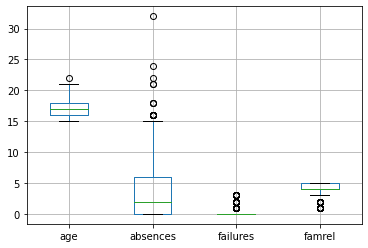

In [606]:
train_x2[['age', 'absences', 'failures', 'famrel']].boxplot()

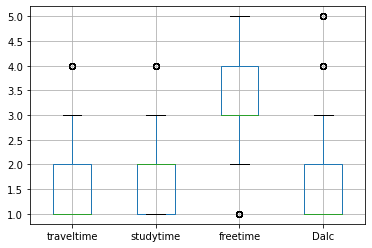

In [607]:
train_x2[['traveltime', 'studytime', 'freetime', 'Dalc']].boxplot()

In [608]:
def f(c):
    sns.distplot(train_x2[c])
    lower_bound = train_x2[c].quantile(0.25)-1.5*(train_x2[c].quantile(0.75)-train_x2[c].quantile(0.25))
    upper_bound = train_x2[c].quantile(0.75)+1.5*(train_x2[c].quantile(0.75)-train_x2[c].quantile(0.25))
    print(lower_bound, upper_bound)

13.0 21.0


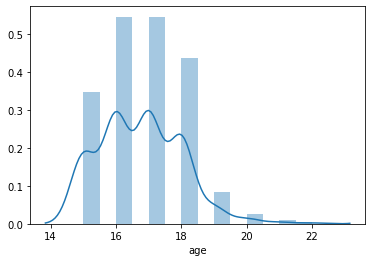

In [609]:
f('age')

-9.0 15.0


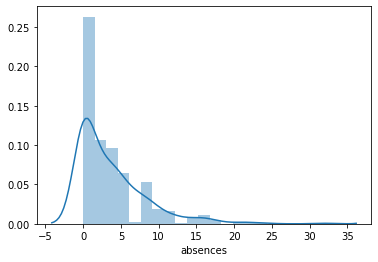

In [610]:
f('absences')

0.0 0.0


D:\Telegram Desktop\anaconda3\lib\site-packages\seaborn\distributions.py:369: UserWarning: Default bandwidth for data is 0; skipping density estimation.
  warnings.warn(msg, UserWarning)


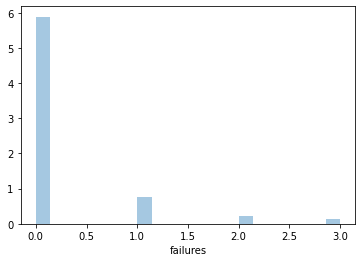

In [611]:
f('failures')

2.5 6.5


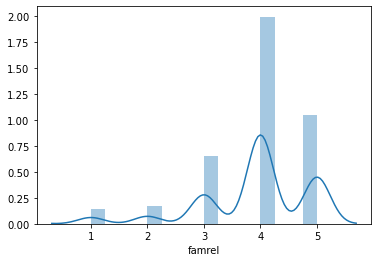

In [612]:
f('famrel')

-0.5 3.5


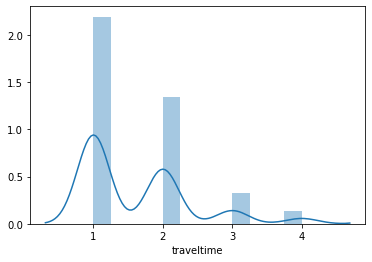

In [613]:
f('traveltime')

-0.5 3.5


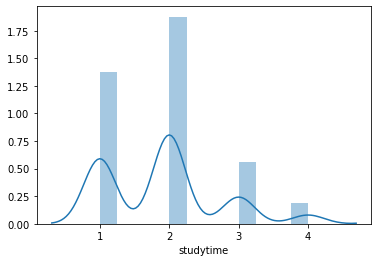

In [614]:
f('studytime')

1.5 5.5


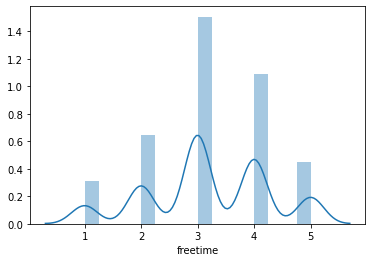

In [615]:
f('freetime')

-0.5 3.5


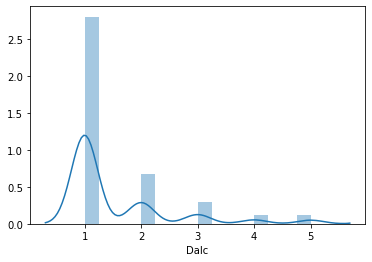

In [616]:
f('Dalc')

In [617]:
train_x2 = train_x2.drop('failures', axis = 1)
train_x2 = train_x2[(train_x2['Dalc'] <4) & (train_x2['famrel'] > 2 ) & (train_x2["absences"] != 24) 
                    & (train_x2["freetime"] > 1) & (train_x2["studytime"] < 4) & (train_x2["traveltime"] < 4)
                   & (train_x2["age"] < 21)]

In [618]:
train_y = train_y.iloc[train_x2.index]

In [619]:
train_x1 = train_x1.drop('failures', axis = 1)

In [620]:
train_y = pd.DataFrame(train_y)

In [621]:
train_y = train_y[train_y['G3'] > 3]

In [622]:
train_x2 = train_x2.loc[train_y.index]

In [623]:
train_x1 = train_x1.loc[train_x2.index]

In [624]:
train_y = train_y.iloc[:,0]

In [625]:
train_x2.columns


Index(['sex', 'age', 'address', 'Medu', 'Fedu', 'traveltime', 'studytime',
       'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences'],
      dtype='object')

In [626]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

In [627]:
train_x2[['sex', 'age', 'address', 'Medu', 'Fedu', 'traveltime', 'studytime',
       'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences']] = scaler.fit_transform(train_x2[['sex', 'age', 'address', 'Medu', 'Fedu', 'traveltime', 'studytime',
       'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences']])
train_x1[['sex', 'age', 'address', 'Medu', 'Fedu', 'traveltime', 'studytime',
       'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences']] = scaler.fit_transform(train_x1[['sex', 'age', 'address', 'Medu', 'Fedu', 'traveltime', 'studytime',
       'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences']])

4.0 20.0


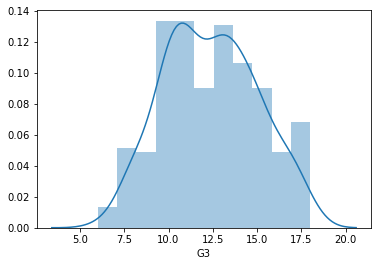

In [628]:
sns.distplot(train_y)
lower_bound = train_y.quantile(0.25)-1.5*(train_y.quantile(0.75)-train_y.quantile(0.25))
upper_bound = train_y.quantile(0.75)+1.5*(train_y.quantile(0.75)-train_y.quantile(0.25))
print(lower_bound, upper_bound)

## KNN

In [629]:
k_acc = [0  for _ in range(100)]

In [630]:
for i in np.arange(2, 101):
    
    for j in range(20):
        new_model = KNeighborsClassifier(n_neighbors = i)
        x_training_data, x_test_data, y_training_data, y_test_data = train_test_split(train_x2, train_y, test_size = 0.3)
        new_model.fit(x_training_data, y_training_data)
        new_predictions = new_model.predict(x_test_data)
        acc = accuracy_score(y_test_data, new_predictions)
        k_acc[i-1] = (k_acc[i-1]*j+acc)/(j+1)

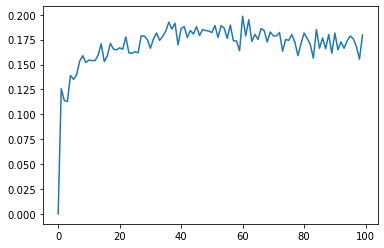

In [631]:
plt.plot(k_acc)

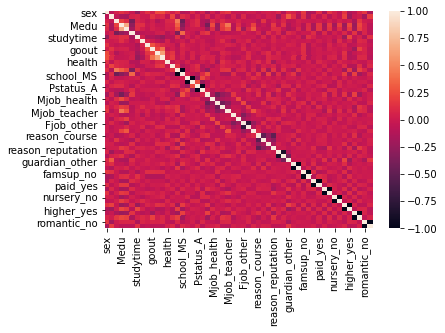

In [632]:
sns.heatmap(train_x1.corr(method = "pearson"))

In [633]:
corr_matrix = train_x1.corr().abs()

In [634]:
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(np.bool))

In [635]:
to_drop = [column for column in upper.columns if any(upper[column] > 0.95)]

In [636]:
train_x1.drop(to_drop, axis=1, inplace=True)

In [637]:
test['sex'] = test['sex'].map(lambda x: 1 if x == 'M' else 0 if x == 'F' else x)
test['address'] = test['address'].map(lambda x: 1 if x == 'U' else 0 if x == 'R' else x)
test = test.drop('failures', axis = 1)
test1= test.select_dtypes(exclude=['object'])

In [638]:
print(train_y.value_counts())

11    49
10    49
13    48
14    39
15    33
12    33
17    19
8     19
16    18
9     18
18     6
7      4
6      1
Name: G3, dtype: int64


In [664]:
for i in range(2, 100):
    new_model = KNeighborsClassifier(n_neighbors = i)
    new_model.fit(train_x1, train_y)
    test2 = test.copy()

    for c in test.columns:
        if test2[c].dtype == np.object:
            test2 = pd.get_dummies(test2, columns=[c])
    test2.drop(to_drop, axis=1, inplace=True)
    new_predictions = new_model.predict(test2)
    if (list(new_predictions).count(10) < 110):
        print(i, new_predictions)

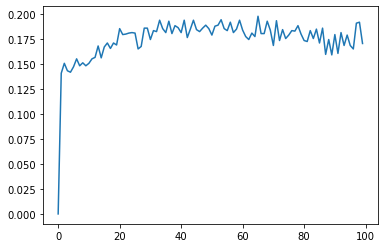

In [640]:
k_acc = [0  for _ in range(100)]

for i in np.arange(2, 101):
    
    for j in range(20):
        new_model = KNeighborsClassifier(n_neighbors = i)
        x_training_data, x_test_data, y_training_data, y_test_data = train_test_split(train_x1, train_y, test_size = 0.3)
        new_model.fit(x_training_data, y_training_data)
        new_predictions = new_model.predict(x_test_data)
        acc = accuracy_score(y_test_data, new_predictions)
        k_acc[i-1] = (k_acc[i-1]*j+acc)/(j+1)
plt.plot(k_acc)

## Bayes

In [286]:
k_acc = [0  for _ in range(100)]

In [287]:
m = []
for i in np.arange(2, 101):
    
    for j in range(20):
        new_model = GaussianNB()
        x_training_data, x_test_data, y_training_data, y_test_data = train_test_split(train_x2, train_y, test_size = 0.3)
        new_model.fit(x_training_data, y_training_data)
        new_predictions = new_model.predict(x_test_data)
        acc = accuracy_score(y_test_data, new_predictions)
        k_acc[i-1] = (k_acc[i-1]*j+acc)/(j+1)

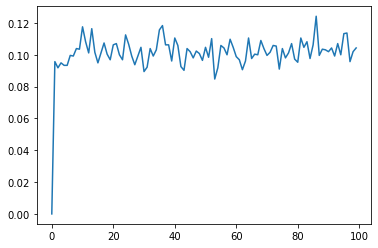

In [288]:
plt.plot(k_acc)

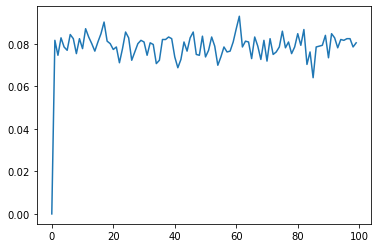

In [289]:
k_acc = [0  for _ in range(100)]

for i in np.arange(2, 101):
    
    for j in range(20):
        new_model = GaussianNB()
        x_training_data, x_test_data, y_training_data, y_test_data = train_test_split(train_x1, train_y, test_size = 0.3)
        new_model.fit(x_training_data, y_training_data)
        new_predictions = new_model.predict(x_test_data)
        acc = accuracy_score(y_test_data, new_predictions)
        k_acc[i-1] = (k_acc[i-1]*j+acc)/(j+1)
plt.plot(k_acc)

## Регрессия

In [290]:
k_acc = [0  for _ in range(100)]

In [291]:
for i in np.arange(2, 101):
    
    for j in range(20):
        new_model = LogisticRegression(solver='liblinear', multi_class='ovr')
        x_training_data, x_test_data, y_training_data, y_test_data = train_test_split(train_x2, train_y, test_size = 0.3)
        new_model.fit(x_training_data, y_training_data)
        new_predictions = new_model.predict(x_test_data)
        acc = accuracy_score(y_test_data, new_predictions)
        k_acc[i-1] = (k_acc[i-1]*j+acc)/(j+1)

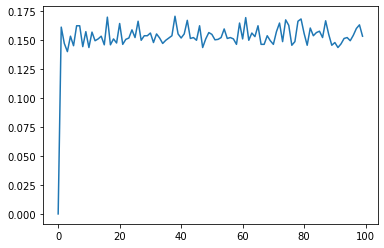

In [292]:
plt.plot(k_acc)

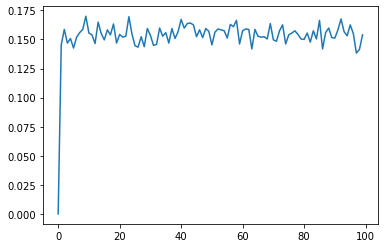

In [293]:
k_acc = [0  for _ in range(100)]

for i in np.arange(2, 101):
    
    for j in range(20):
        new_model = LogisticRegression(solver='liblinear', multi_class='ovr')
        x_training_data, x_test_data, y_training_data, y_test_data = train_test_split(train_x1, train_y, test_size = 0.3)
        new_model.fit(x_training_data, y_training_data)
        new_predictions = new_model.predict(x_test_data)
        acc = accuracy_score(y_test_data, new_predictions)
        k_acc[i-1] = (k_acc[i-1]*j+acc)/(j+1)
plt.plot(k_acc)

## SVM

In [294]:
k_acc = [0  for _ in range(100)]

In [295]:
for i in np.arange(2, 101):
    
    for j in range(20):
        new_model = SVC(gamma=0.001, C = 100)
        x_training_data, x_test_data, y_training_data, y_test_data = train_test_split(train_x2, train_y, test_size = 0.3)
        new_model.fit(x_training_data, y_training_data)
        new_predictions = new_model.predict(x_test_data)
        acc = accuracy_score(y_test_data, new_predictions)
        k_acc[i-1] = (k_acc[i-1]*j+acc)/(j+1)

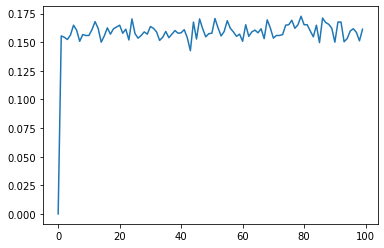

In [296]:
plt.plot(k_acc)

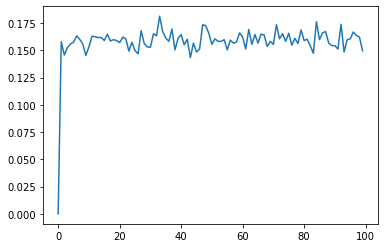

In [299]:
k_acc = [0  for _ in range(100)]

for i in np.arange(2, 101):
    
    for j in range(20):
        new_model = SVC(gamma=0.001, C = 100)
        
        x_training_data, x_test_data, y_training_data, y_test_data = train_test_split(train_x1, train_y, test_size = 0.3)
        new_model.fit(x_training_data, y_training_data)
        new_predictions = new_model.predict(x_test_data)
        acc = accuracy_score(y_test_data, new_predictions)
        k_acc[i-1] = (k_acc[i-1]*j+acc)/(j+1)
plt.plot(k_acc)

## Постройте сложную модель на основе предыдущих четырех простых и оцените ее точность

Вариант 1. Нужно взвесить предсказания простых моделей. Предложите метод взвешивания.

In [50]:
from scipy.stats import ttest_rel
import xgboost as xgb
from sklearn.model_selection import cross_val_predict

In [45]:
scores_100_trees = np.array([])
scores_110_trees = np.array([])
for i in range(10):
    fold = KFold(n_splits=5, shuffle=True, random_state=i)
    scores_100_trees_on_this_split = cross_val_score(
                                             estimator=xgb.XGBRegressor(
                                                        n_estimators=100),
                                             X=train_x2, y=train_y,
                                             cv=fold, scoring='r2')
    scores_100_trees = np.append(scores_100_trees,
                                 scores_100_trees_on_this_split)
    scores_110_trees_on_this_split = cross_val_score(
                                            estimator=xgb.XGBRegressor(
                                                        n_estimators=110),
                                            X=train_x2, y=train_y,
                                            cv=fold, scoring='r2')
    scores_110_trees = np.append(scores_110_trees,
                                 scores_110_trees_on_this_split)
ttest_rel(scores_100_trees, scores_110_trees) 

Ttest_relResult(statistic=1.0716058728838498, pvalue=0.28914689575160674)

01234567890123456789012345678901234567890123456789012345678901234567890123456789012345678901234567890123456789012345678901234567890123456789012345678901234567890123456789012345678901234567890123456789012345678901234567890123456789012345678901234567890123456789012345678901234567890123456789012345678901234567890123456789012345678901234567890123456789012345678901234567890123456789012345678901234567890123456789012345678901234567890123456789012345678901234567890123456789012345678901234567890123456789

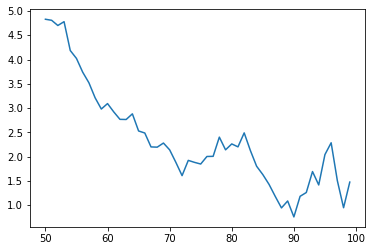

In [46]:
t_stats = []
n_trees = []
for j in range(50, 100):
    current_score = np.array([])
    for i in range(10):
        print(i, end = '')
        fold = KFold(n_splits=5, shuffle=True, random_state=i)
        scores_on_this_split = cross_val_score(
                                      estimator=xgb.XGBRegressor(
                                                   n_estimators=j),
                                      X=train_x2, y=train_y,
                                      cv=fold, scoring='r2')
        current_score = np.append(current_score,
                                  scores_on_this_split)
    t_stat, p_value = ttest_rel(current_score, scores_100_trees)
    t_stats.append(t_stat)
    n_trees.append(j)
plt.plot(n_trees, t_stats)

In [52]:
base_estimator = xgb.XGBRegressor(min_child_weight=2)
pred_train = cross_val_predict(estimator=base_estimator, X=train_x2, y=train_y, cv=5)
abs_train_error = np.absolute(train_y - pred_train)
outlier_mask = (abs_train_error > 3)
print (f'Outliers fraction in train = {float(train_y[outlier_mask].shape[0]) / train_y.shape[0]}')

Outliers fraction in train = 0.3247058823529412


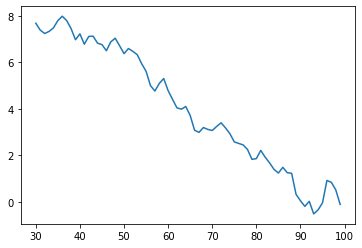

In [61]:

from sklearn.metrics import r2_score
base_scores_train_v2 = np.array([])
for i in range(10):
    fold = KFold(n_splits=5, shuffle=True, random_state=i)
    scores_on_this_split = cross_val_score(
                                        estimator=xgb.XGBRegressor(
                                           min_child_weight=2),
                                        X=train_x2,
                                        y=train_y,
                                        scoring='r2', cv=fold)
    base_scores_train_v2 = np.append(base_scores_train_v2,
                                     scores_on_this_split)
t_stats_train_v2 = []
for j in range(30, 100):
    scores_train_v2 = np.array([])
    for i in range(10):
        fold = KFold(n_splits=5, shuffle=True, random_state=i)
        scores_on_this_split = cross_val_score(
                                        estimator=xgb.XGBRegressor(
                                            n_estimators=j,
                                            min_child_weight=2),
                                        X=train_x2,
                                        y=train_y,
                                        scoring='r2', cv=fold)
        scores_train_v2 = np.append(scores_train_v2,
                                    scores_on_this_split)
    t_stat,p_value = ttest_rel(scores_train_v2, base_scores_train_v2)
    t_stats_train_v2.append(t_stat)
plt.plot(range(30,100), t_stats_train_v2)

Вариант 2. Нужно оценить корреляцию предсказаний простых моделей.

## Сделайте итоговое предсказание

Решением домашнего задания является данный ноутбук + .csv файл с предсказанием. Пример формата файла, который должен у вас получится приведен в ```data/sample_submission.csv```. Данные для предсказания - ```X_test.csv```.

За лучшее предсказание 5 человек получат +10% к домашке.

Значения предсказаний должны быть целочисленными. Проверка будет точности решения будет по MSE.

In [663]:
# Для jupyter notebook

submission = pd.read_csv('sample_submission.csv', index_col='id')

submission['G3'] = m[40].predict(test)
submission.to_csv('submission1.csv', index=False) 

IndexError: list index out of range

In [743]:
test0 = pd.read_csv('X_test.csv')

In [744]:
train0 = train = pd.read_csv('train_features_with_answers.csv')

In [745]:
test0['is_test'] = 1

In [746]:
train0['is_test'] = 0

In [747]:
test0 = test0.select_dtypes(exclude=['object'])
test0 = test0.dropna()
train0 = train0.select_dtypes(exclude=['object'])
train0 = train0.dropna()

In [748]:
test0_y = test0['is_test']
test0_x = test0.drop('is_test', axis = 1)
train0_y = train0['is_test']
train0_x = train0.drop('is_test', axis = 1)

In [749]:
k_acc = [0  for _ in range(100)]

In [751]:
for i in np.arange(3, 101):

    new_model = GaussianNB()
    x_training_data, x_test_data, y_training_data, y_test_data = train_test_split(train0_x, train0_y, test_size = 0.33, shuffle=True)
    
    new_model.fit(test0_x, test0_y)
    new_model.partial_fit(x_training_data, y_training_data)
    new_predictions = new_model.predict(x_test_data)
    acc = accuracy_score(y_test_data, new_predictions)
    print(acc)

ValueError: Number of features 14 does not match previous data 13.